# Project Stochastic Simulation SRN

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import math
import scipy.stats as stats

## Section 2.1

### 2.1.1
Stochiometric vectors and propensity functions

In [2]:
nu = np.array([[-1, -1, 1, 0],[1, 1, -1, 0],[0,1,-1,1]]) # stochiometric vectors

def aCalc(x, c):
    a1 = c[0]*(x[0]*x[1])*(x[0]>=1 and x[1]>=1)
    a2 = c[1]*(x[2])*(x[2]>=1)
    a3 = c[2]*(x[2])*(x[2]>=1)
    return np.array([a1, a2, a3])

### 2.1.2

Consider the following rate constants: c1 = 0.0017, c2 = 10−4
, c3 = 0.1 and the
following initial conditions X1(0) = 312, X2(0) = 125, X3(0) = X4(0) = 0. Using the
SSA algorithm, simulate the reactions until time exceeds T = 50. Plot few realizations
of the evolution in time of each state Xi(t) and comment your results.

In [3]:
def SSA_alg(c, X0, T):

    '''
    SSA_alg takes the rate constants list c, inital condition array X0 and final time T.
    It returns an array of states X, and an array of times at wich a reaction occured.
    '''

    X = []
    X.append(X0)

    t = [0]
    n = 0
    while (t[-1]<T):
        a = aCalc(X[n], c)
        aSum = sum(a)

        u = np.random.uniform(0,1)
        P = a/aSum # Vector holding the probability of each reaction
        #F = np.array([P[0], P[0]+P[1] , P[0]+P[1]+P[2]])
        if u < P[0]:
            j = 0
        elif u < P[0]+P[1] :
            j = 1
        else :
            j = 2

        X.append(X[n]+nu[j])
        tau = np.random.exponential(1/aSum)

        t.append(t[-1] +tau)
        n += 1
    return np.array(X), np.array(t)

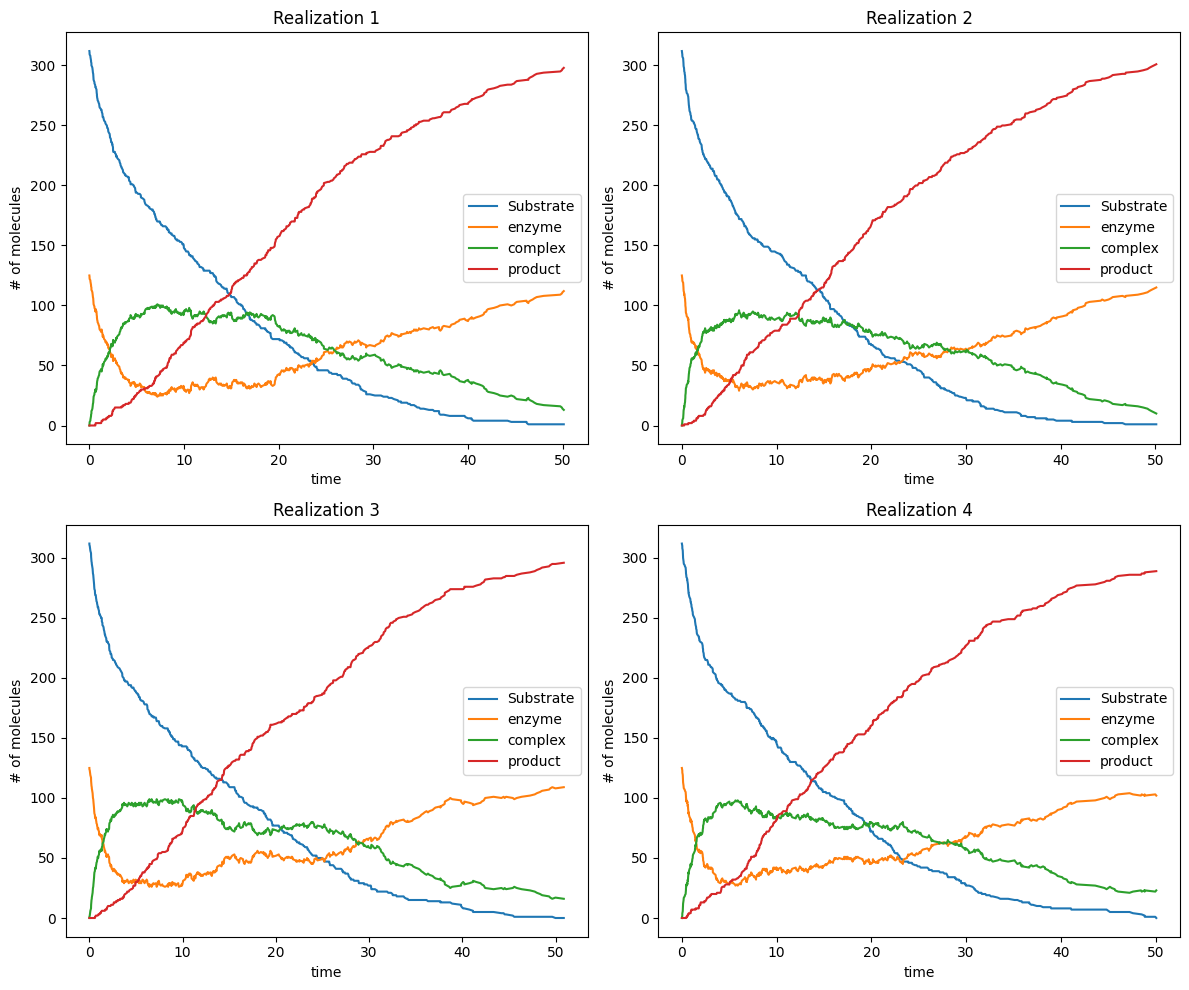

In [4]:
c = [0.0017, 1e-4, 0.1] # rate constants
T = 50 # Total time
X0 = np.array([312, 125, 0, 0])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i in range(4): # Loop for 4 realizations
    X, t = SSA_alg(c, X0, T)

    axes[i].plot(t, X[:,0], label="Substrate")
    axes[i].plot(t, X[:,1], label="enzyme")
    axes[i].plot(t, X[:,2], label="complex")
    axes[i].plot(t, X[:,3], label="product")

    axes[i].set_title(f"Realization {i+1}")
    axes[i].set_xlabel("time")
    axes[i].set_ylabel("# of molecules")
    axes[i].legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### 2.1.3
Estimate with Monte Carlo the quantity of interest Z = E(X4(T)).
Fix a threshold for the halfwidth of a confidence interval at level 1-alpha and iteratively increase N until you achieve the desired tolerance.

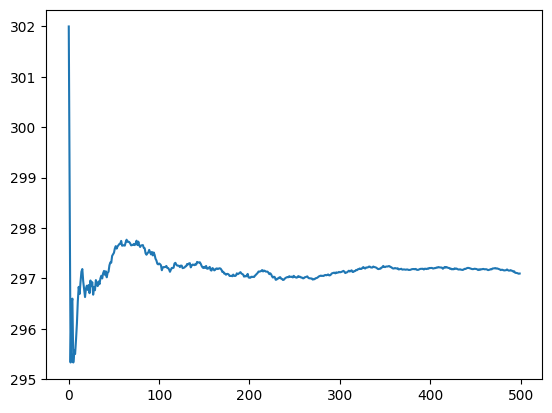

In [5]:
'''
Test plot to estimate a good Nb
'''

Nb = 500
X4 = np.zeros(Nb)
muNs= [0]

for i in range(Nb):
    X, t = SSA_alg(c, X0, T)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])

plt.plot(range(0, Nb), muNs[1:])

In [6]:
Nb = 150
X4 = np.zeros(Nb)
muNs= [0]
for i in range(Nb):
    X, t = SSA_alg(c, X0, T)
    X4[i] = X[-1,3]
    muNs.append((i/(i+1))*muNs[-1] + 1/(i+1) * X[-1,3])

alpha = 0.05  # for 95% confidence
cAlph = stats.norm.ppf(1 - alpha/2)
tol = 0.2

muNb = 1/Nb * sum(X4)
sigNb = np.sqrt(1/(Nb-1) * sum((X4 - muNb)**2))

N, muN, sigN = Nb, muNb, sigNb

while (sigN * cAlph/np.sqrt(N) > tol):

    N = N+1

    X, t = SSA_alg(c, X0, T)

    muN = (N/(N+1))*muN + 1/(N+1) * X[-1,3]
    sigN = np.sqrt((N-1)/N * sigN**2 + 1/(N+1) * (X[-1,3] - muN)**2)

In [7]:
print("95% confidence interval for mu: [", muN-(sigN * cAlph/np.sqrt(N)),' , ',muN+(sigN * cAlph/np.sqrt(N)),']')
print("Calculated by N = ", N, " iterations")

95% confidence interval for mu: [ 296.59331021700785  ,  296.99315636962586 ]
Calculated by N =  1665  iterations


### 2.1.4
Consider c = [0.001, 0.005, 0.01] and intial state X[0] = [100, 100, 0, 0], final time T=1.
Using a CMC estimator compute Z = E(g(X(t))) = E(indicator (X3(T)>22)).
Based on different sample sizes give an estimate of variance associated with the estimator. What do you observe?

In [8]:
c = [0.001, 0.005, 0.01]
X0 = np.array([100, 100, 0, 0])
T = 1

N = np.array([100, 500, 1000, 3000, 100000])
indX3 = []
for n in N: # iterating through sample sizes n in N
    X3 = np.zeros(n) # array for saving the n values of X3(T)

    for i in range(n): # generating n realisations of X
        X, t = SSA_alg(c, X0, T)
        X3[i] = X[-1,2] # Saving each X3(T), final row, third column

    indX3.append(sum(X3>22))

muInd = indX3/N
varInd = 1/(N-1) * sum((indX3 - muInd)**2)

In [9]:
indX3 = np.array(indX3)
muInd = indX3/N
varInd = 1/(N-1) * sum((indX3 - muInd)**2)

print("mu^[ind(X3>22)] = ", muInd)
print("Var[mu^] = ", varInd/N)

mu^[ind(X3>22)] =  [0.e+00 0.e+00 0.e+00 0.e+00 5.e-05]
Var[mu^] =  [2.52520202e-03 1.00198397e-04 2.50245245e-05 2.77864844e-06
 2.49997500e-09]


### 2.1.5

Consider the implementation of importance sampling strategy to approximate Z = E(indicator). The importance dist. is contructed by modifying c1 -> c1 tilde etc. Choose heuristic values for the new rate constants. Justify your choice and quantify the variance reduction obtained.

We change the c values according to the report -> increasing the chances of obtaining $\{X_{3}>22\}$ means: $\tilde{c_{1}} > c_{1}$, $\tilde{c_{2}}<c_{2}$ and $\tilde{c_{3}} < c_{3}$. We experimented with different values, and changing each of the constants by $0.001$ in the desired direction was already clearly increasing the number of \{$X_{3}>22$\}.

In [129]:
# Here we experimented with different constant rates changes.
c_tilde = [0.003, 0.003, 0.008]
X0 = np.array([100, 100, 0, 0])
T = 1

N = np.array([100, 500, 1000, 3000, 10000])
indX3 = []
for n in N: # iterating through sample sizes n in N
    X3 = np.zeros(n) # array for saving the n values of X3(T)

    for i in range(n): # generating n realisations of X
        X, t = SSA_alg(c_tilde, X0, T)
        # print("i:" + str(X[-1,2]))
        X3[i] = X[-1,2] # Saving each X3(T), final row, third column


    indX3.append(sum(X3>22))

print(indX3)
muInd = indX3/N
varInd = 1/(N-1) * sum((indX3 - muInd)**2)


print("mu^[ind(X3>22)] = ", muInd)
print("Var[mu^] = ", varInd/N)
X3


[np.int64(68), np.int64(332), np.int64(659), np.int64(1942), np.int64(6477)]
mu^[ind(X3>22)] =  [0.68       0.664      0.659      0.64733333 0.6477    ]
Var[mu^] =  [4.67269876e+03 1.85409690e+02 4.63060237e+01 5.14168253e+00
 4.62643441e-01]


array([22., 22., 26., ..., 23., 22., 14.])

In [12]:
#
def SSA_IS_alg(c_original, c_tilde, X0, T):
    # c_original: array of original rate constants
    # c_tilde: array of tilted rate constants used for sampling


    x = X0.copy()
    t = 0.0
    logW = 0.0          # log weight accumulator


    # saving trajectory
    X = [x.copy()]
    times = [0.0]

    while t < T:
        a  = aCalc(x, c_original)   # original propensities
        at = aCalc(x, c_tilde)      # tilted propensities

        a0  = a.sum()
        at0 = at.sum()

        if at0 == 0:
            # no reaction possible: only integrate remaining time
            logW += -(a0 - at0) * (T - t)
            break

        # waiting time using TILTED intensity
        tau = np.random.exponential(1/at0)

        # If next event exceeds T: stop
        if t + tau > T:
            logW += -(a0 - at0) * (T - t)
            t = T
            break

        # Add integral contribution for [t, t+tau]
        logW += -(a0 - at0) * tau

        # choose reaction under TILTED probabilities
        probs = at / at0
        j = np.random.choice(3, p=probs)

        # Reaction likelihood ratio term
        if a[j] == 0:
            # path impossible under original → weight = 0
            return np.array(X), np.array(times), 0.0

        logW += np.log(a[j]) - np.log(at[j])

        # Fire reaction
        x = x + nu[j]
        t = t + tau

        X.append(x.copy())
        times.append(t)

    W = np.exp(logW)
    return np.array(X), np.array(times), W


In [130]:
c_original = [0.001, 0.005, 0.01]     # <-- original task values
c_tilde    = [0.0015, 0.0030, 0.005]    # <-- newly chosen task values


IS_estimates = []
IS_variances = []
ESS_values = []

for n in N:
    contributions = np.zeros(n)  # stores W * indicator
    weights = np.zeros(n)

    for i in range(n):
        X, t, W = SSA_IS_alg(c_original, c_tilde, X0, T)
        g = (X[-1,2] > 22)

        contributions[i] = W * g
        weights[i] = W

    # IS estimate of P(X3>22)
    p_hat = contributions.mean()

    # variance estimate of IS estimator:
    var_hat = contributions.var(ddof=1) / n

    # effective sample size
    ESS = (weights.sum()**2) / (np.sum(weights**2) + 1e-16)

    IS_estimates.append(p_hat)
    IS_variances.append(var_hat)
    ESS_values.append(ESS)

print("IS estimate p(X3>22) = ", [float(x) for x in IS_estimates])
print("Var estimator = ", [float(x) for x in IS_variances])
print("ESS = ", [float(x) for x in ESS_values])


IS estimate p(X3>22) =  [0.0, 1.4699521525422279e-05, 8.746903284595763e-06, 4.87966038334906e-06, 5.242480326170341e-06]
Var estimator =  [0.0, 1.0858347072788948e-10, 2.7977865125064208e-11, 6.17936912960818e-12, 1.7771028706447265e-12]
ESS =  [29.11693351018827, 118.8026855375182, 307.82332680503544, 513.5949410124317, 1811.1139928017828]


## Section 3.1

### 3.1.2

In [ ]:

c = [0.0017, 1e-4, 0.1] # rate constants

T = 1 # Total time
tau = 0.2

X = np.zeros((251,4))
X[0] = [312, 125, 0, 0] # Initial # of each species

t = 0
n = 0
while (t<T): #########

    a = aCalc(X[n])
    aSum = sum(a)

    P = np.random.poisson(lam = (aCalc(X[n])*tau)) # (3,) array of pj values
    X[n+1] = X[n] + P @ nu

    t += tau
    n += 1

X = np.transpose(X)
plt.plot(range(0, n), X[0][0:n], label="Substrate")
plt.plot(range(0, n), X[1][0:n], label="enzyme")
plt.plot(range(0, n), X[2][0:n], label="complex")
plt.plot(range(0, n), X[3][0:n], label="product")
plt.legend()
plt.show()